# Inicjalizacja | Feature Engineering | Random Forest

In [1]:
import pandas as pd
import numpy as np
import glob
from sklearn.ensemble import RandomForestClassifier

print("="*80)
print(">>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING MODELU MATKI <<<")
print("="*80)

# 1. WCZYTANIE DANYCH 
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ground_truth_final.csv')
df_train_raw = df_train_raw[df_train_raw['Refined_Label'] != 'Background Noise'].copy()

test_files = glob.glob('../dane/testowe/*.csv')
dfs_test = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files]
df_test_raw = pd.concat(dfs_test, ignore_index=True) if dfs_test else pd.DataFrame()

print(f"[*] Wczytano Złoty Standard (Trening): {len(df_train_raw)} rekordów.")
print(f"[*] Wczytano Surowe Logi (Przyszłość): {len(df_test_raw)} rekordów.")

# 2. WSPÓLNA FUNKCJA INŻYNIERII CECH
known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

FEATURES = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Proto_Enc', 'State_Enc', 'Dport_Num']

def prepare_ml_features(df_input):
    df = df_input.copy()
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
    
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    
    df['Proto_Enc'] = df.get('Proto', '').apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').apply(lambda x: safe_encode(x, known_states))
    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    return df

print("[*] Aplikowanie inżynierii cech do obu zbiorów...")
df_train = prepare_ml_features(df_train_raw)
df_test = prepare_ml_features(df_test_raw)

X_train = df_train[FEATURES].fillna(0)
y_train = df_train['Refined_Label']

# 3. TRENING GŁÓWNEGO MODELU
print("[*] Trenowanie klasyfikatora Random Forest (class_weight='balanced')...")
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
print("[+] Model gotowy i uzbrojony!\n")

>>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING MODELU MATKI <<<
[*] Wczytano Złoty Standard (Trening): 65572 rekordów.
[*] Wczytano Surowe Logi (Przyszłość): 44308 rekordów.
[*] Aplikowanie inżynierii cech do obu zbiorów...
[*] Trenowanie klasyfikatora Random Forest (class_weight='balanced')...
[+] Model gotowy i uzbrojony!



# Ewaluacja wewnętrzna

>>> KROK 2: WIZUALIZACJA ROC-AUC ORAZ PRECISION-RECALL (EWALUACJA WEWNĘTRZNA) <<<
[*] Trenowanie modelu ewaluacyjnego na podzbiorze 80%...
[+] SUKCES! Zapisano wykresy w: ../wykresy\9_rf_roc_pr_curves.png


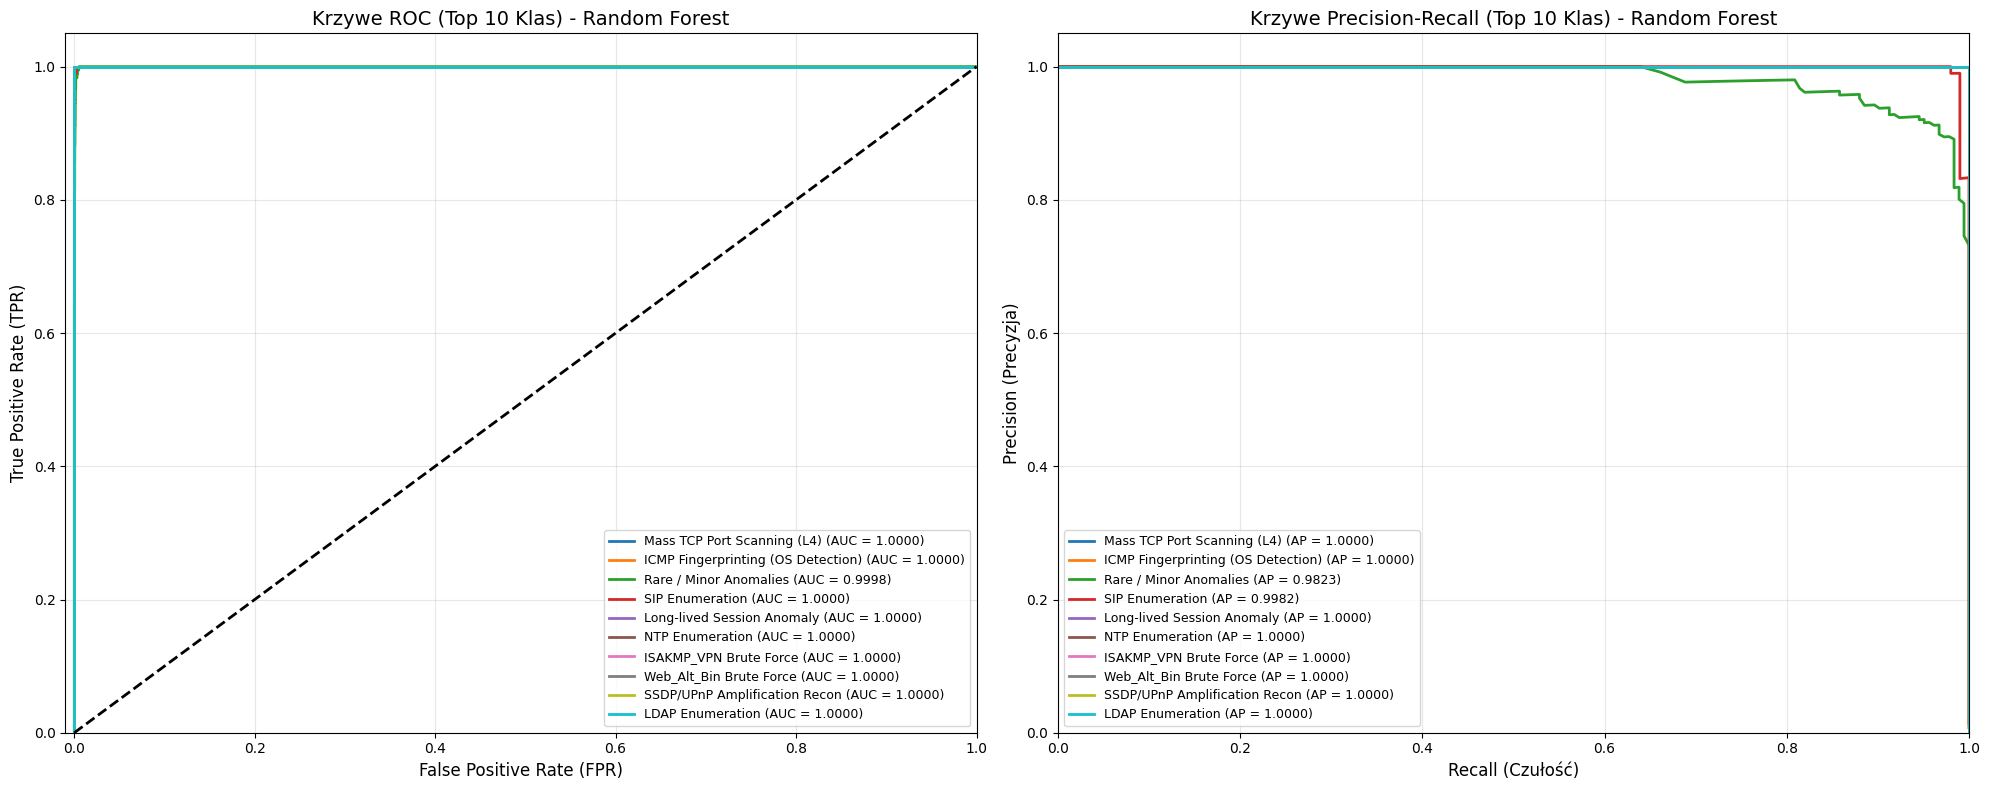

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import os

print("="*80)
print(">>> KROK 2: WIZUALIZACJA ROC-AUC ORAZ PRECISION-RECALL (EWALUACJA WEWNĘTRZNA) <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# 1. KLASYCZNY PODZIAŁ 80/20 NA GOTOWYM ZBIORZE TRENINGOWYM
X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

# 2. SZYBKI TRENING EWALUACYJNY
print("[*] Trenowanie modelu ewaluacyjnego na podzbiorze 80%...")
clf_eval = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
clf_eval.fit(X_train_ev, y_train_ev)

# 3. PRZYGOTOWANIE DO WYKRESÓW (One-vs-Rest)
classes = clf_eval.classes_
y_test_bin = label_binarize(y_test_ev, classes=classes)
n_classes = y_test_bin.shape[1]
y_score = clf_eval.predict_proba(X_test_ev)

fpr, tpr, roc_auc = dict(), dict(), dict()
precision, recall, average_precision = dict(), dict(), dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

# Wybieramy Top 10 klas do czytelnego wykresu
top_classes_names = y_test_ev.value_counts().head(10).index
top_classes_idx = [np.where(classes == name)[0][0] for name in top_classes_names]
colors = sns.color_palette("tab10", len(top_classes_idx))

# 4. RYSOWANIE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for idx, color in zip(top_classes_idx, colors):
    class_name = classes[idx]
    ax1.plot(fpr[idx], tpr[idx], color=color, lw=2, label=f'{class_name} (AUC = {roc_auc[idx]:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([-0.01, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title('Krzywe ROC (Top 10 Klas) - Random Forest', fontsize=14)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

for idx, color in zip(top_classes_idx, colors):
    class_name = classes[idx]
    ax2.plot(recall[idx], precision[idx], color=color, lw=2, label=f'{class_name} (AP = {average_precision[idx]:.4f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Czułość)', fontsize=12)
ax2.set_ylabel('Precision (Precyzja)', fontsize=12)
ax2.set_title('Krzywe Precision-Recall (Top 10 Klas) - Random Forest', fontsize=14)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
file_path = os.path.join(output_dir, '9_rf_roc_pr_curves.png')
plt.savefig(file_path, dpi=300)
print(f"[+] SUKCES! Zapisano wykresy w: {file_path}")
plt.show()

# Inferencja Zero-Day | Paszport (Przyszłość)

In [3]:
print("="*100)
print(">>> KROK 3: INFERENCJA ZERO-DAY ORAZ PASZPORT DPI (DANE Z PRZYSZŁOŚCI) <<<")
print("="*100)

# 1. PREDYKCJA MODELEM MATKĄ
X_new = df_test[FEATURES].fillna(0)

print("[*] Skanowanie nowego ruchu (z progiem pewności 75%)...")
CONFIDENCE_THRESHOLD = 0.75

probs = clf.predict_proba(X_new)
max_probs = np.max(probs, axis=1)
pred_indices = np.argmax(probs, axis=1)
predicted_classes = clf.classes_[pred_indices]

# Nakładamy filtr pewności i zapisujemy decyzję do "surowego" DataFrame
df_test_raw['System_Decision'] = np.where(max_probs >= CONFIDENCE_THRESHOLD, predicted_classes, 'UNKNOWN_Zero_Day')

# 2. RAPORT ZAGROŻEŃ (ZLICZANIE ODRZUTÓW)
report_counts = df_test_raw['System_Decision'].value_counts()
unknown_percent = (report_counts.get('UNKNOWN_Zero_Day', 0) / len(df_test_raw)) * 100
print(f"\n[!] Ruch odrzucony jako UNKNOWN (Potencjalny Szum / Zero-Day): {unknown_percent:.2f}%\n")

# 3. GENEROWANIE PASZPORTU DPI DLA DECYZJI MODELU
def get_mode(x):
    m = pd.Series.mode(x)
    return m.iloc[0] if not m.empty else "N/A"

report = df_test_raw.groupby('System_Decision').agg({
    'Dur': 'median',
    'TotPkts': 'median',
    'State': get_mode,
    'Dport': get_mode,
    'srcUdata': lambda x: x.dropna().iloc[0] if not x.dropna().empty else "[Brak Payloadu]"
}).reset_index()

report['Liczność'] = report['System_Decision'].map(report_counts)
report = report.sort_values(by='Liczność', ascending=False)

print(f"{'DECYZJA MODELU RF':<35} | {'LICZNOŚĆ':<9} | {'PORT':<6} | {'PKT':<4} | {'STATE':<6} | {'PRÓBKA Z PAYLOADU (DPI)'}")
print("-" * 120)

for _, row in report.iterrows():
    p_clean = str(row['srcUdata']).replace('\n', ' ').replace('\r', ' ')
    if len(p_clean) > 40:
        p_clean = p_clean[:37] + "..."
        
    print(f"{str(row['System_Decision']):<35} | {int(row['Liczność']):<9} | {str(row['Dport']):<6} | {int(row['TotPkts']):<4} | {str(row['State']):<6} | {p_clean}")
print("="*120)

>>> KROK 3: INFERENCJA ZERO-DAY ORAZ PASZPORT DPI (DANE Z PRZYSZŁOŚCI) <<<
[*] Skanowanie nowego ruchu (z progiem pewności 75%)...

[!] Ruch odrzucony jako UNKNOWN (Potencjalny Szum / Zero-Day): 99.93%

DECYZJA MODELU RF                   | LICZNOŚĆ  | PORT   | PKT  | STATE  | PRÓBKA Z PAYLOADU (DPI)
------------------------------------------------------------------------------------------------------------------------
UNKNOWN_Zero_Day                    | 44278     | 445    | 3    | SR_RA  | s[54]=..................................
ISAKMP_VPN Brute Force              | 30        | 500    | 600  | REQ    | s[480]=5*..I'..........! "........."....
